## Домашнее задание 4
### Полушина Дарья Б06-303

### Часть 1 — Сборка с Velvet

Для выполнения этой части работы были взяты файлы из папки `genome_de_novo`: 7_S4_L001_R1_001.fastq и 7_S4_L001_R2_001.fastq. Была выполнена сборка с разными кмерами (31, 41, 51, 61) с помощью программы Velvet.

Скрипты приведены ниже:

Скриншот папки на сервере c созданными файлами сборки velvet (команда ls -la --time=ctime):

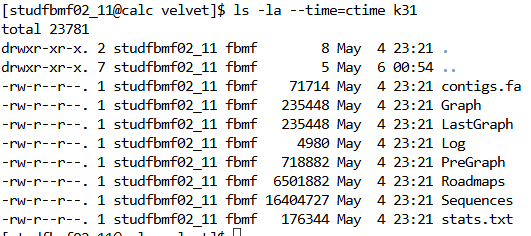
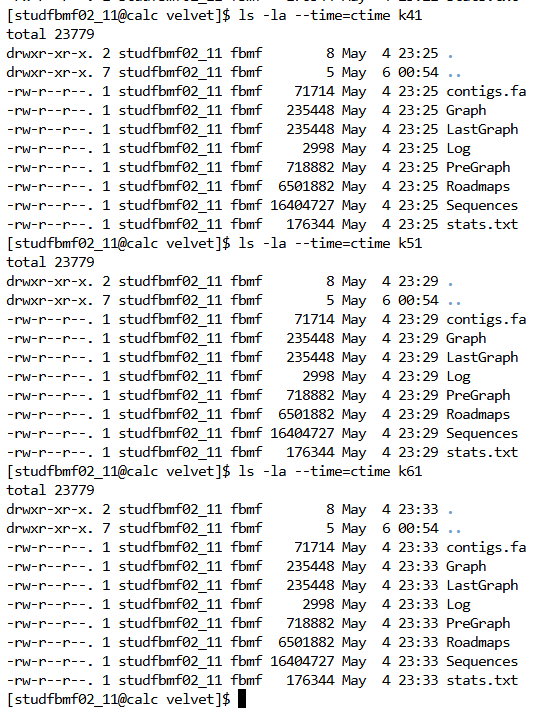

Состав файлов в папке сборки:
- contigs.fa — финальные контиги
- Graph — бинарный граф сборки
- LastGraph — текстовое представление графа
- Log — лог выполнения
- PreGraph — граф до обработки
- Roadmaps — информация о парных ридах
- Sequences — все последовательности
- stats.txt — статистика сборки

### Часть 2 — Сравнение сборок

С помощью QUAST сравним сборки Velvet и SPAdes.

Скрипт для сборки SPAdes:

Скрипты для QUAST, которые создают репорты для сборок, с помощью которых можно сравнить сборки:

**Выводы:**

Таблица для SPAdes:
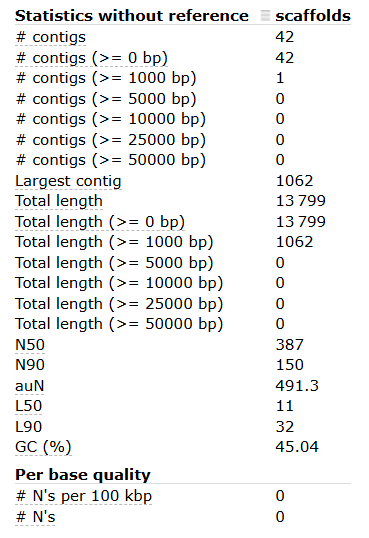

Таблица для Velvet (k41):
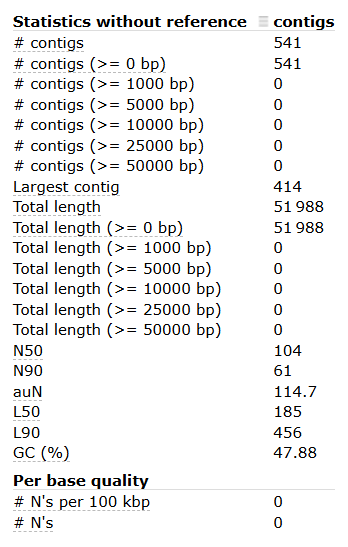

SPAdes значительно превосходит Velvet по качеству сборки:
- В 13 раз меньше контигов (42 против 541)
- Самый длинный контиг в 2.5 раза длиннее (1062 bp против 414 bp)
- N50 в 3.7 раза выше (387 bp против 104 bp), N90 d 2.5 раза (150 bp против 61 bp)

Velvet дал фрагментированную сборку, что характерно для этого ассемблера при работе со сложными данными или короткими ридами. Все контиги короче 500 bp, что свидетельствует о низкой связности графа.

SPAdes показал более целостную сборку благодаря лучшей обработке ошибок в ридах, лучшему использованию парных ридов и адаптивному подбору кмеров.

GC-состав различается (47.88% у Velvet и 45.04% у SPAdes), что может указывать на наличие артефактов в сборке Velvet или разную стратегию обработки повторов.

**Лучшая сборка: SPAdes**, так как она даёт более длинные и целостные контиги, а также более связный граф за счёт современных алгоритмов коррекции ошибок и автоматической настройки параметров.

### Часть 3 — Улучшение сборки

**Как можно улучшить сборку:**

**Для Velvet:**
- удалять очень короткие контиги (<200 bp), которые часто являются шумом
- определять порог покрытия, чтобы сразу отсекать ошибочные контиги (например, артефакты с низким покрытием)
- определять ожидаемое покрытие генома для разрешения повторов

**Для SPAdes:**
- также определять порог покрытия, чтобы сразу отсекать ошибочные контиги с низким покрытием
- исправлять однонуклеотидные ошибки и инделы
- расширить диапазон кмеров (так как короткие лучше соединяют участки с низким покрытием, а длинные лучше разрешают сложные повторы)

Ниже приведены скрипты с улучшеными сборками на основе данных пунктов и QUAST:

Таблица улучшенной сборки для SPAdes:
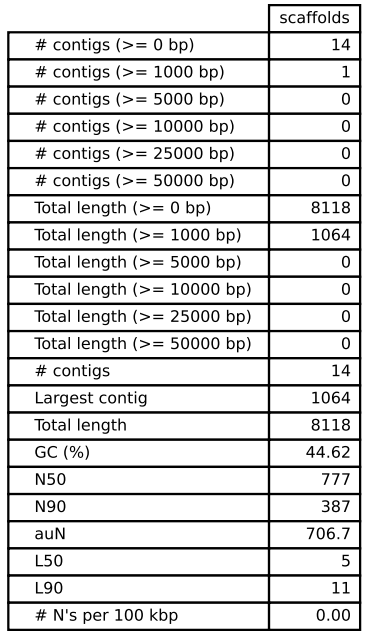

Таблица улучшенной сборки Velvet (k41):
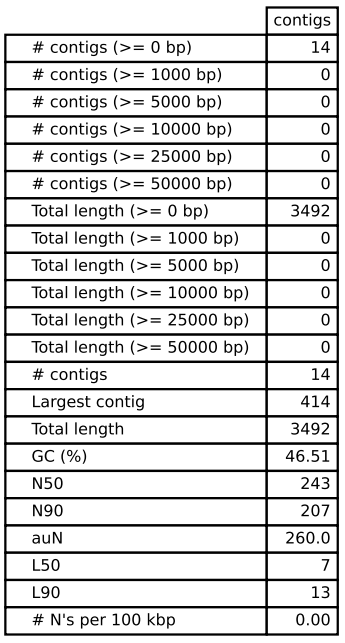

**Сравнение сборок:**

**Улучшение Velvet:**
- число контигов упало почти в 40 раз (с 541 до 14)
- N50 и N90 выросли в 2 с лишним раза
- total length уменьшилась с 51988 до 3492 bp, то есть отсеклись артефакты
- сборка улучшилась, параметры `-cov_cutoff auto`, `-exp_cov auto`, `-min_contig_lgth 200` позволили отсечь огромное количество шумовых контигов, которые были артефактами. Осталось 14 наиболее достоверных контигов.

**Улучшение SPAdes:**
- число контигов уменьшилось тоже до 14 (но это уже в 3 раза)
- N50 и N90 выросли в 2 раза
- немного улучшилась и выросла максимальная длина
- `--careful` и расширенный диапазон k-mer (21,33,55,77,99,127) улучшили качество сборки и уменьшили количество контигов

**Сравнение улучшенных Velvet и SPAdes:**
- число контигов стало равным
- по остальным параметрам SPAdes все также лучше (как в части 2: N50, N90, largest contig, total length)

### Итоговые выводы

В ходе работы была выполнена сборка генома с использованием Velvet для 4-х разных кмеров. Все сборки Velvet показали идентичные статистические характеристики независимо от выбранного кмера. Полученные контиги оказались крайне короткими, а общее количество контигов указывает на высокую фрагментацию сборки. Далее была выполнена сборка SPAdes, которая оказалась гораздо более современной и удачной: лучше корректировала ошибки и обрабатывала данные, получились более длинные и целостные контиги. Далее выяснилось, что с помощью различных параметрова можно улучшить каждую из сборок, но SPAdes все равно показал более хорошие результаты.